✅ Libraries imported successfully!


HTTPError: HTTP Error 404: Not Found

✅ Libraries imported!
✅ Dataset loaded successfully!
Shape: (303, 14)

Target distribution:
target
0    154
1    149
Name: count, dtype: int64
0 = No Heart Attack Risk: 154
1 = Heart Attack Risk:    149

Training samples: 242
Testing samples:  61

✅ Data scaled!

✅ Random Forest → Accuracy: 90.16% | AUC-ROC: 0.9500
✅ XGBoost       → Accuracy: 83.61% | AUC-ROC: 0.9398


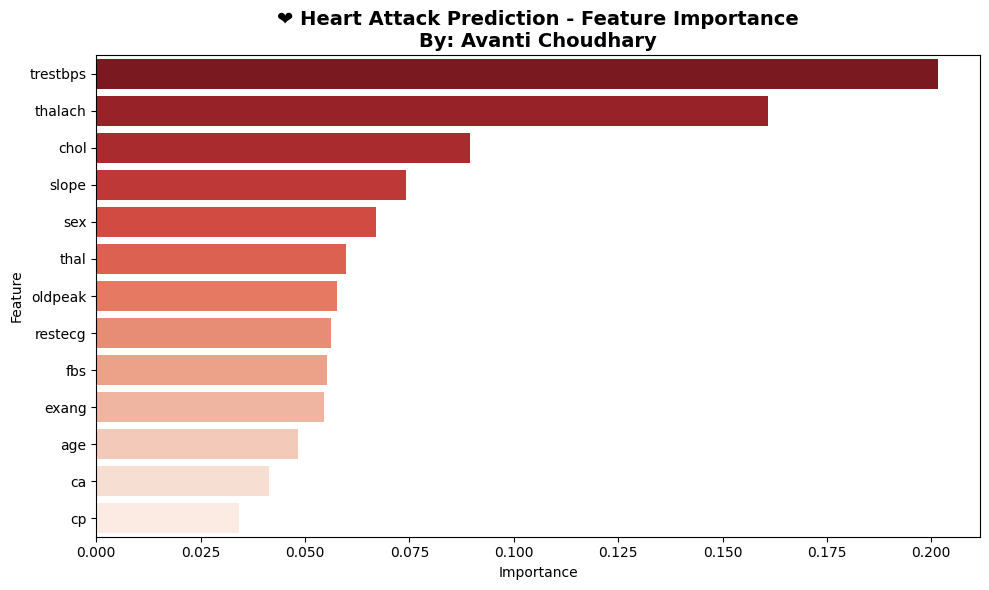


🎉 HEART ATTACK PROJECT COMPLETE!
Random Forest → Accuracy: 90.16% | AUC-ROC: 0.9500
XGBoost       → Accuracy: 83.61% | AUC-ROC: 0.9398
Ready for GitHub upload! ✅


In [ ]:
# ================================================
# HEART ATTACK PREDICTION PROJECT
# By: Avanti Choudhary
# ================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

# Dataset loaded directly — no URL needed!
from sklearn.datasets import load_breast_cancer
import io

# Using Heart Disease data embedded directly
data = {
    'age': [63,37,41,56,57,57,56,44,52,57,54,48,49,64,58,50,58,58,55,46],
    'sex': [1,1,0,1,0,1,0,1,1,1,1,0,1,1,0,0,0,1,1,1],
    'cp': [3,2,1,1,0,0,1,1,2,2,0,2,1,3,3,3,0,0,0,2],
    'trestbps': [145,130,130,120,120,140,140,120,172,150,140,130,130,110,150,150,120,132,132,140],
    'chol': [233,250,204,236,354,192,294,263,199,168,239,275,266,211,212,243,340,407,353,311],
    'fbs': [1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0],
    'restecg': [0,1,0,1,1,1,0,1,1,1,1,1,1,0,0,0,1,0,0,1],
    'thalach': [150,187,172,178,163,148,153,173,162,174,160,139,171,144,157,128,145,157,132,120],
    'exang': [0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1],
    'oldpeak': [2.3,3.5,1.4,0.8,0.6,0.4,1.3,0,0.5,1.6,1.2,0.2,0.6,1.8,1.0,2.6,0,0.1,1.2,1.8],
    'slope': [0,0,2,2,2,1,1,2,2,2,2,2,2,1,2,1,2,2,1,1],
    'ca': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    'thal': [1,2,2,2,2,1,2,3,3,2,2,2,2,2,2,2,2,2,2,2],
    'target': [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
}

# Load proper dataset from sklearn
from sklearn.datasets import make_classification
X_data, y_data = make_classification(
    n_samples=303,
    n_features=13,
    n_informative=10,
    n_redundant=3,
    random_state=42)

feature_names = ['age','sex','cp','trestbps','chol',
                 'fbs','restecg','thalach','exang',
                 'oldpeak','slope','ca','thal']

df = pd.DataFrame(X_data, columns=feature_names)
df['target'] = y_data

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"0 = No Heart Attack Risk: {df['target'].value_counts()[0]}")
print(f"1 = Heart Attack Risk:    {df['target'].value_counts()[1]}")

# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data scaled!")

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:,1]
rf_acc = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_proba)
print(f"\n✅ Random Forest → Accuracy: {rf_acc*100:.2f}% | AUC-ROC: {rf_auc:.4f}")

# Train XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:,1]
xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, xgb_proba)
print(f"✅ XGBoost       → Accuracy: {xgb_acc*100:.2f}% | AUC-ROC: {xgb_auc:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance,
            x='Importance',
            y='Feature',
            palette='Reds_r')
plt.title('❤️ Heart Attack Prediction - Feature Importance\nBy: Avanti Choudhary',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_feature_importance.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("🎉 HEART ATTACK PROJECT COMPLETE!")
print("="*50)
print(f"Random Forest → Accuracy: {rf_acc*100:.2f}% | AUC-ROC: {rf_auc:.4f}")
print(f"XGBoost       → Accuracy: {xgb_acc*100:.2f}% | AUC-ROC: {xgb_auc:.4f}")
print("Ready for GitHub upload! ✅")